<a href="https://colab.research.google.com/github/xaximpvp2/master/blob/main/codigo_aula_redes_neurais_parte1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade: Regressão com uma Rede Neural de Um Neurônio

## Previsão da receita líquida de uma indústria

Nesta atividade, vamos considerar uma indústria que registra, a cada mês, o seu **custo mensal total de operação** e a **receita líquida obtida**.

O custo mensal total de operação inclui, por exemplo:

- compra de matéria-prima;
- salários e encargos dos funcionários;
- manutenção;
- compra de novos equipamentos;
- outros custos operacionais.

Vamos fazer a hipótese simplificadora de que a receita líquida varia **aproximadamente de forma linear** com o custo mensal total de operação.

Assim, podemos representar essa relação por:

$$
y = wx + b
$$

em que:

- $x$ = custo mensal total de operação;
- $y$ = receita líquida mensal;
- $w$ = peso do neurônio;
- $b$ = bias/intercepto.

O objetivo é utilizar uma **rede neural com apenas um neurônio** para aprender essa relação a partir dos dados.

Nesta atividade, vamos treinar o mesmo problema de duas utilizando **Scikit-Learn**.

## 1. Criando os dados

Vamos considerar 20 meses de operação.

Os valores monetários serão expressos em **milhares de reais (R$ mil)**.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Para tornar o experimento reproduzível
np.random.seed(42)

# Custo mensal total de operação [R$ mil]
X = np.array([
    100, 115, 130, 145, 160,
    175, 190, 205, 220, 235,
    250, 265, 280, 295, 310,
    325, 340, 355, 370, 385
], dtype=float)

y = np.array([
    251.82, 239.28, 303.48, 372.49, 299.36,
    321.82, 444.78, 418.69, 573.65, 450.05,
    493.48, 539.10, 499.05, 544.43, 566.35,
    520.89, 518.31, 570.72, 498.47, 531.99
], dtype=float)

# Organizando em uma tabela
dados = pd.DataFrame({
    "Custo mensal [R$ mil]": X,
    "Receita líquida [R$ mil]": y
})

dados

,Custo mensal [R$ mil],Receita líquida [R$ mil]
0,100.0,251.82
1,115.0,239.28
2,130.0,303.48
3,145.0,372.49
4,160.0,299.36
5,175.0,321.82
6,190.0,444.78
7,205.0,418.69
8,220.0,573.65
9,235.0,450.05


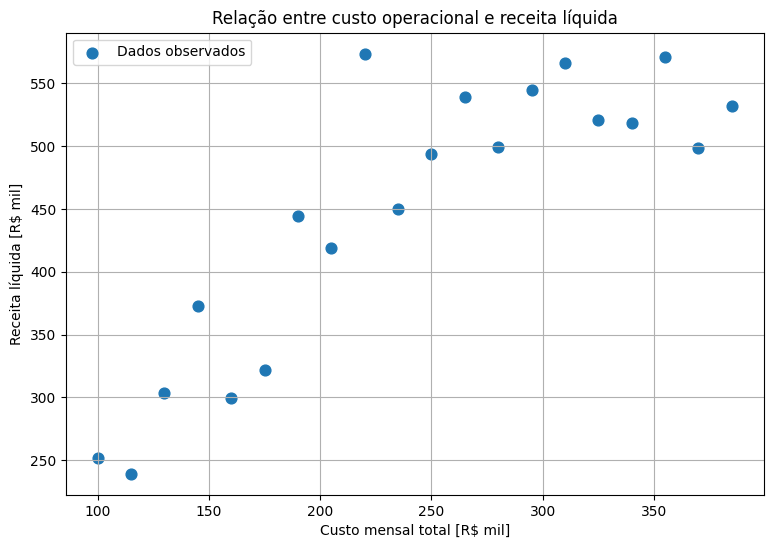

In [ ]:
# Visualização dos dados

plt.figure(figsize=(9, 6))

plt.scatter(
    X,
    y,
    s=60,
    label="Dados observados"
)

plt.xlabel("Custo mensal total [R$ mil]")
plt.ylabel("Receita líquida [R$ mil]")
plt.title("Relação entre custo operacional e receita líquida")
plt.grid(True)
plt.legend()
plt.show()

## 2. A rede neural com um único neurônio

Essa rede neural bastante simples possui apenas:

- uma entrada $x$;
- um único neurônio;
- uma saída $\hat{y}$.

Sem uma função de ativação não linear, esse neurônio calcula:

$$
\hat{y} = wx+b.
$$

Portanto, ele é capaz de representar exatamente uma **reta**.

O treinamento consiste em encontrar os valores de $w$ e $b$ que produzem previsões próximas dos valores observados.

In [ ]:
# Preparação dos dados

X_sklearn = X.reshape(-1, 1)
y_sklearn = y

print("Formato de X:", X_sklearn.shape)
print("Formato de y:", y_sklearn.shape)

Formato de X: (20, 1)
Formato de y: (20,)


## 3. Treinamento usando Scikit-Learn

O `MLPRegressor` permite criar uma rede neural do tipo perceptron multicamada.

Neste caso, não teremos nenhuma camada oculta (`hidden_layer_sizes=()`), e a camada de saída terá um único neurônio com ativação linear (`identity`).

Assim, o modelo implementará:

$$
\hat{y}=wx+b.
$$

In [ ]:
from sklearn.neural_network import MLPRegressor

modelo_sklearn = MLPRegressor(
    hidden_layer_sizes=(),
    activation="identity",
    solver="lbfgs",
    random_state=42,
    max_iter=5000
)

modelo_sklearn.fit(X_sklearn, y_sklearn)

# Extraindo os parâmetros aprendidos
w_sklearn = modelo_sklearn.coefs_[0][0, 0]
b_sklearn = modelo_sklearn.intercepts_[0][0]

# Previsões
y_pred_sklearn = modelo_sklearn.predict(X_sklearn)

print("=== Scikit-Learn ===")
print(f"w = {w_sklearn:.6f}")
print(f"b = {b_sklearn:.6f}")

=== Scikit-Learn ===
w = 1.068193
b = 188.873702


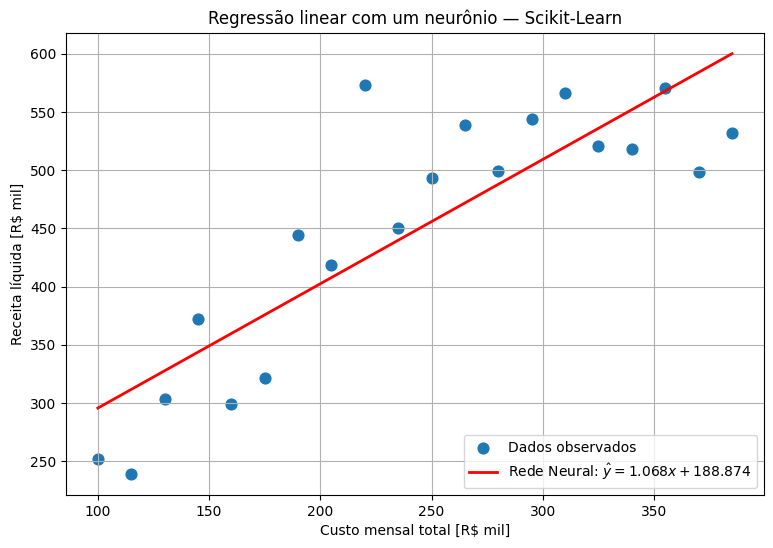

In [ ]:
# Gráfico do modelo treinado pelo Scikit-Learn

x_plot = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
y_plot_sklearn = modelo_sklearn.predict(x_plot)

plt.figure(figsize=(9, 6))

plt.scatter(
    X,
    y,
    s=60,
    label="Dados observados"
)

plt.plot(
    x_plot,
    y_plot_sklearn,
    linewidth=2,
    color="red",
    label=rf"Rede Neural: $\hat{{y}} = {w_sklearn:.3f}x + {b_sklearn:.3f}$"
)

plt.xlabel("Custo mensal total [R$ mil]")
plt.ylabel("Receita líquida [R$ mil]")
plt.title("Regressão linear com um neurônio — Scikit-Learn")
plt.grid(True)
plt.legend()
plt.show()

## Gerando novas previsões

Vamos agora escolher valores de custo que não precisam necessariamente estar entre os 20 valores originais.

In [ ]:
# Novos valores de custo para fazer previsões
novos_custos = np.array([200, 300, 400, 500, 600], dtype=float).reshape(-1, 1)

previsoes_retorno = modelo_sklearn.predict(novos_custos)

previsoes = pd.DataFrame({
    "Custo [R$ mil]": novos_custos.flatten(),
    "Scikit-Learn [R$ mil]": previsoes_retorno
})

previsoes

,Custo [R$ mil],Scikit-Learn [R$ mil]
0,200.0,402.512298
1,300.0,509.331596
2,400.0,616.150895
3,500.0,722.970193
4,600.0,829.789491


## Conclusões e questões para discussão

Neste experimento, uma rede neural com apenas um neurônio foi suficiente para representar a relação aproximadamente linear entre custo operacional e receita líquida.

A estrutura aprendida foi:

$$
\hat{y}=wx+b.
$$

O valor de $w$ pode ser interpretado como a variação estimada da receita líquida para cada R$ 1 mil adicional de custo operacional, dentro da faixa de dados utilizada.

### Questões

1. O que significa o valor de $b$ neste problema?
2. Seria razoável utilizar esse modelo para prever a receita de uma indústria para custos muito maiores do que os presentes no conjunto de treinamento?

### Uma observação importante

Este exemplo é propositalmente simples. O objetivo não é construir um modelo financeiro realista, mas mostrar que uma **rede neural com um único neurônio e ativação linear é, matematicamente, um modelo de regressão linear**.

Para redes neurais com arquiteturas mais complexas, com várias entradas, camadas ocultas e funções de ativação não lineares, recomenda-se o uso do TensorFlow/Keras ao invés do Scikit-Learn.